# IE 6600 Project 2 - NHTSA Vehicle Recalls

**Advanced Data Analysis and Visualization Using Seaborn**

Team Members: Shweta Gaikwad, Sai Dikshin, Sai Sabareesh KS

This notebook contains the full code required for the Project 2 report: data loading, inspection, cleaning, campaign-level preparation, Seaborn visualizations, saved image files, summary tables, and statistical checks.

## IE 6600 Project 2 Advanced Data Analysis and Visualization Using Seaborn Dataset: NHTSA Vehicle Recalls Team Members: Shweta Gaikwad, Sai Dikshin, Sai Sabareesh KS

In [1]:
# 1. Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Seaborn theme for clean static visualizations
sns.set_theme(style="whitegrid", context="notebook")

# Figure settings
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"

In [3]:
# 2. File paths

In [4]:
DATA_PATH = Path("nhtsa_recalls-1.csv")
FIG_DIR = Path("figures")
TABLE_DIR = Path("tables")

FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

In [5]:
# 3. Load and inspect the dataset

In [6]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print("Raw dataset shape:", df_raw.shape)
print("\nFirst five rows:")
print(df_raw.head())

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

# Missing values summary
missing_values = df_raw.isna().sum().sort_values(ascending=False).reset_index()
missing_values.columns = ["Column", "Missing Values"]
missing_values["Percent Missing"] = (missing_values["Missing Values"] / len(df_raw) * 100).round(2)

print("\nTop missing-value columns:")
print(missing_values.head(12))

missing_values.to_csv(TABLE_DIR / "missing_values_summary.csv", index=False)

Raw dataset shape: (240137, 21)

First five rows:
   RECORD_ID     CAMPNO       MAKETXT     MODELTXT  YEARTXT   COMPNAME  \
0      81715  10V454000  FOREST RIVER  CEDAR CREEK     2003  EQUIPMENT   
1      81716  10V454000  FOREST RIVER   CHARLESTON     2004  EQUIPMENT   
2      81717  10V454000  FOREST RIVER    BERKSHIRE     2007  EQUIPMENT   
3      81718  10V454000  FOREST RIVER     CARDINAL     2001  EQUIPMENT   
4      81719  10V423000        PIERCE     ARROW XT     2001   STEERING   

                MFGNAME       BGMAN      ENDMAN RCLTYPECD  ...       ODATE  \
0    FOREST RIVER, INC.         NaN         NaN         V  ...  2011-01-28   
1    FOREST RIVER, INC.         NaN         NaN         V  ...  2011-01-28   
2    FOREST RIVER, INC.         NaN         NaN         V  ...  2011-01-28   
3    FOREST RIVER, INC.         NaN         NaN         V  ...  2011-01-28   
4  PIERCE MANUFACTURING  1998-05-30  2008-11-25         V  ...  2010-10-12   

  INFLUENCED_BY                MFGTX

In [7]:
# 4. Data cleaning and preparation

In [8]:
df = df_raw.copy()

# Standardize important text columns
text_cols = [
    "MAKETXT", "MODELTXT", "COMPNAME", "MFGNAME", "RCLTYPECD",
    "INFLUENCED_BY", "MFGTXT", "DO_NOT_DRIVE", "PARK_OUTSIDE"
]

for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .replace({"NAN": np.nan, "": np.nan})
        )

# Convert date columns
date_cols = ["ODATE", "RCDATE", "DATEA", "BGMAN", "ENDMAN"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Convert numeric columns
df["YEARTXT"] = pd.to_numeric(df["YEARTXT"], errors="coerce")
df["POTAFF"] = pd.to_numeric(df["POTAFF"], errors="coerce")

# Remove exact duplicate rows
initial_rows = len(df)
df = df.drop_duplicates()
duplicates_removed = initial_rows - len(df)

# Create derived variables
df["recall_year"] = df["RCDATE"].dt.year
df["vehicle_age_at_recall"] = df["recall_year"] - df["YEARTXT"]

# Remove unrealistic vehicle ages
df.loc[
    (df["vehicle_age_at_recall"] < 0) | (df["vehicle_age_at_recall"] > 80),
    "vehicle_age_at_recall"
] = np.nan

# Log transform affected units for distribution charts
df["affected_log10"] = np.log10(df["POTAFF"].clip(lower=1))

# Create a special safety flag
df["safety_flag"] = np.where(
    (df["DO_NOT_DRIVE"] == "YES") | (df["PARK_OUTSIDE"] == "YES"),
    "Special flag",
    "No special flag"
)

print("\nDuplicate rows removed:", duplicates_removed)
print("Cleaned dataset shape:", df.shape)


Duplicate rows removed: 0
Cleaned dataset shape: (240137, 25)


In [9]:
# 5. Create campaign-level dataset

In [10]:
def mode_value(x):
    """Return the most common value in a pandas Series."""
    m = x.mode(dropna=True)
    return m.iat[0] if not m.empty else np.nan

campaign = (
    df.sort_values("RCDATE")
      .groupby("CAMPNO", as_index=False)
      .agg(
          first_recall_date=("RCDATE", "min"),
          recall_year=("recall_year", "min"),
          make=("MAKETXT", mode_value),
          component=("COMPNAME", mode_value),
          manufacturer=("MFGNAME", mode_value),
          potential_affected=("POTAFF", "max"),
          model_year_min=("YEARTXT", "min"),
          model_year_max=("YEARTXT", "max"),
          do_not_drive=("DO_NOT_DRIVE", lambda x: "YES" if (x == "YES").any() else "NO"),
          park_outside=("PARK_OUTSIDE", lambda x: "YES" if (x == "YES").any() else "NO"),
          influenced_by=("INFLUENCED_BY", mode_value),
          records=("RECORD_ID", "count")
      )
)

campaign["affected_log10"] = np.log10(campaign["potential_affected"].clip(lower=1))

campaign["safety_flag"] = np.where(
    (campaign["do_not_drive"] == "YES") | (campaign["park_outside"] == "YES"),
    "Special flag",
    "No special flag"
)

campaign["model_year_span"] = campaign["model_year_max"] - campaign["model_year_min"] + 1
campaign["model_year_mid"] = (campaign["model_year_min"] + campaign["model_year_max"]) / 2
campaign["approx_vehicle_age"] = campaign["recall_year"] - campaign["model_year_mid"]

print("\nCampaign-level shape:", campaign.shape)
print(campaign.head())

campaign.to_csv("cleaned_campaign_level_data.csv", index=False)


Campaign-level shape: (14912, 18)
      CAMPNO first_recall_date  recall_year       make        component  \
0  10C001000        2010-02-04         2010  MAXI-COSI  CHILD SEAT:BASE   
1  10C003000        2010-07-26         2010      CYBEX       CHILD SEAT   
2  10C005000        2010-10-13         2010    EVENFLO       CHILD SEAT   
3  10C006000        2010-10-28         2010     BRITAX       CHILD SEAT   
4  10E002000        2010-02-11         2010     TOYOTA       SUSPENSION   

                manufacturer  potential_affected  model_year_min  \
0       DOREL JUVENILE GROUP               22850            9999   
1                REGAL LAGER                 881            9999   
2      EVENFLO COMPANY, INC.               13792            9999   
3  BRITAX CHILD SAFETY, INC.               17251            9999   
4          RIDE CONTROL, LLC               12657            1986   

   model_year_max do_not_drive park_outside influenced_by  records  \
0            9999           NO     

In [11]:
# 6. Summary tables for report

In [12]:
quality_summary = pd.DataFrame({
    "Property": [
        "Raw rows",
        "Cleaned rows",
        "Columns",
        "Unique recall campaigns",
        "Recall years",
        "Unique makes",
        "Unique components",
        "Exact duplicate rows removed",
        "Median affected units/campaign",
        "90th percentile affected units",
        "Do Not Drive campaigns",
        "Park Outside campaigns"
    ],
    "Value": [
        f"{len(df_raw):,}",
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        f"{campaign['CAMPNO'].nunique():,}",
        f"{int(campaign['recall_year'].min())}-{int(campaign['recall_year'].max())}",
        f"{campaign['make'].nunique():,}",
        f"{campaign['component'].nunique():,}",
        f"{duplicates_removed:,}",
        f"{campaign['potential_affected'].median():,.0f}",
        f"{campaign['potential_affected'].quantile(0.90):,.0f}",
        f"{(campaign['do_not_drive'] == 'YES').sum():,}",
        f"{(campaign['park_outside'] == 'YES').sum():,}"
    ]
})

quality_summary.to_csv(TABLE_DIR / "quality_summary.csv", index=False)
print("\nQuality summary:")
print(quality_summary)

top_makes = campaign["make"].value_counts().head(15).reset_index()
top_makes.columns = ["Make", "Campaign Count"]
top_makes.to_csv(TABLE_DIR / "top_makes.csv", index=False)

top_components = campaign["component"].value_counts().head(15).reset_index()
top_components.columns = ["Component", "Campaign Count"]
top_components.to_csv(TABLE_DIR / "top_components.csv", index=False)

yearly_campaigns = (
    campaign
    .dropna(subset=["recall_year"])
    .groupby("recall_year")
    .size()
    .reset_index(name="unique_campaigns")
)
yearly_campaigns.to_csv(TABLE_DIR / "yearly_campaigns.csv", index=False)

component_summary = (
    campaign
    .groupby("component", as_index=False)
    .agg(
        campaigns=("CAMPNO", "count"),
        median_affected=("potential_affected", "median"),
        p90_affected=("potential_affected", lambda x: np.nanpercentile(x, 90)),
        special_flags=("safety_flag", lambda x: (x == "Special flag").sum())
    )
    .sort_values(["campaigns", "median_affected"], ascending=False)
)

component_summary.to_csv(TABLE_DIR / "component_summary.csv", index=False)


Quality summary:
                          Property      Value
0                         Raw rows    240,137
1                     Cleaned rows    240,137
2                          Columns         25
3          Unique recall campaigns     14,912
4                     Recall years  2010-2026
5                     Unique makes      1,553
6                Unique components        590
7     Exact duplicate rows removed          0
8   Median affected units/campaign        474
9   90th percentile affected units     52,374
10          Do Not Drive campaigns        201
11          Park Outside campaigns         94


In [13]:
# 7. Helper function to save charts

In [14]:
def save_plot(file_name):
    """Save each chart as PNG and PDF."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{file_name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{file_name}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [15]:
# 8. Figure 1 - Recall campaigns over time

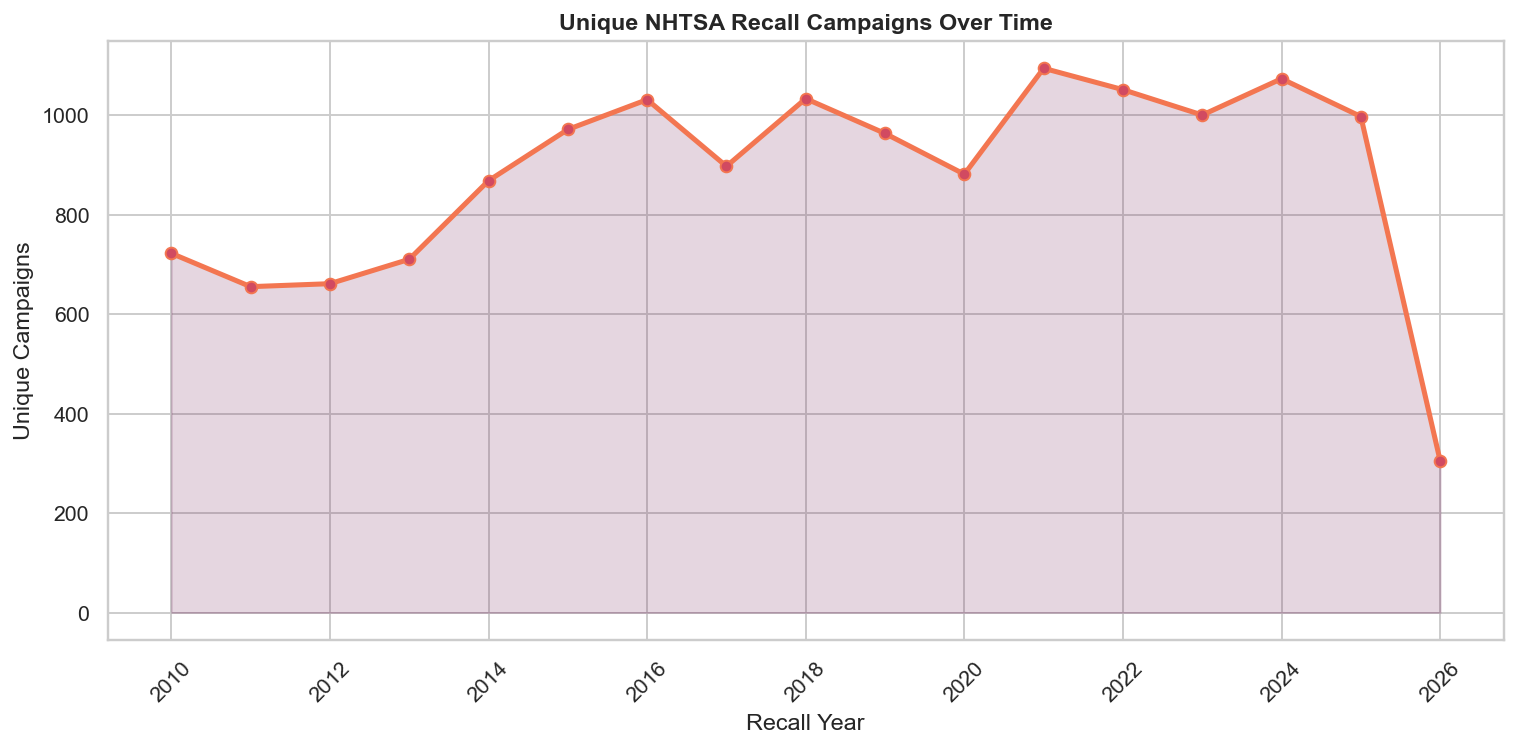

In [16]:
plt.figure(figsize=(11, 5.5))

line_color = sns.color_palette("rocket", 6)[4]
fill_color = sns.color_palette("rocket", 6)[1]
marker_color = sns.color_palette("flare", 6)[2]

plt.plot(
    yearly_campaigns["recall_year"],
    yearly_campaigns["unique_campaigns"],
    marker="o",
    linewidth=2.6,
    color=line_color,
    markersize=6,
    markerfacecolor=marker_color
)

plt.fill_between(
    yearly_campaigns["recall_year"],
    yearly_campaigns["unique_campaigns"],
    color=fill_color,
    alpha=0.18
)

plt.title("Unique NHTSA Recall Campaigns Over Time")
plt.xlabel("Recall Year")
plt.ylabel("Unique Campaigns")
plt.xticks(rotation=45)

save_plot("figure_01_campaigns_over_time")

In [17]:
# 9. Figure 2 - Top makes

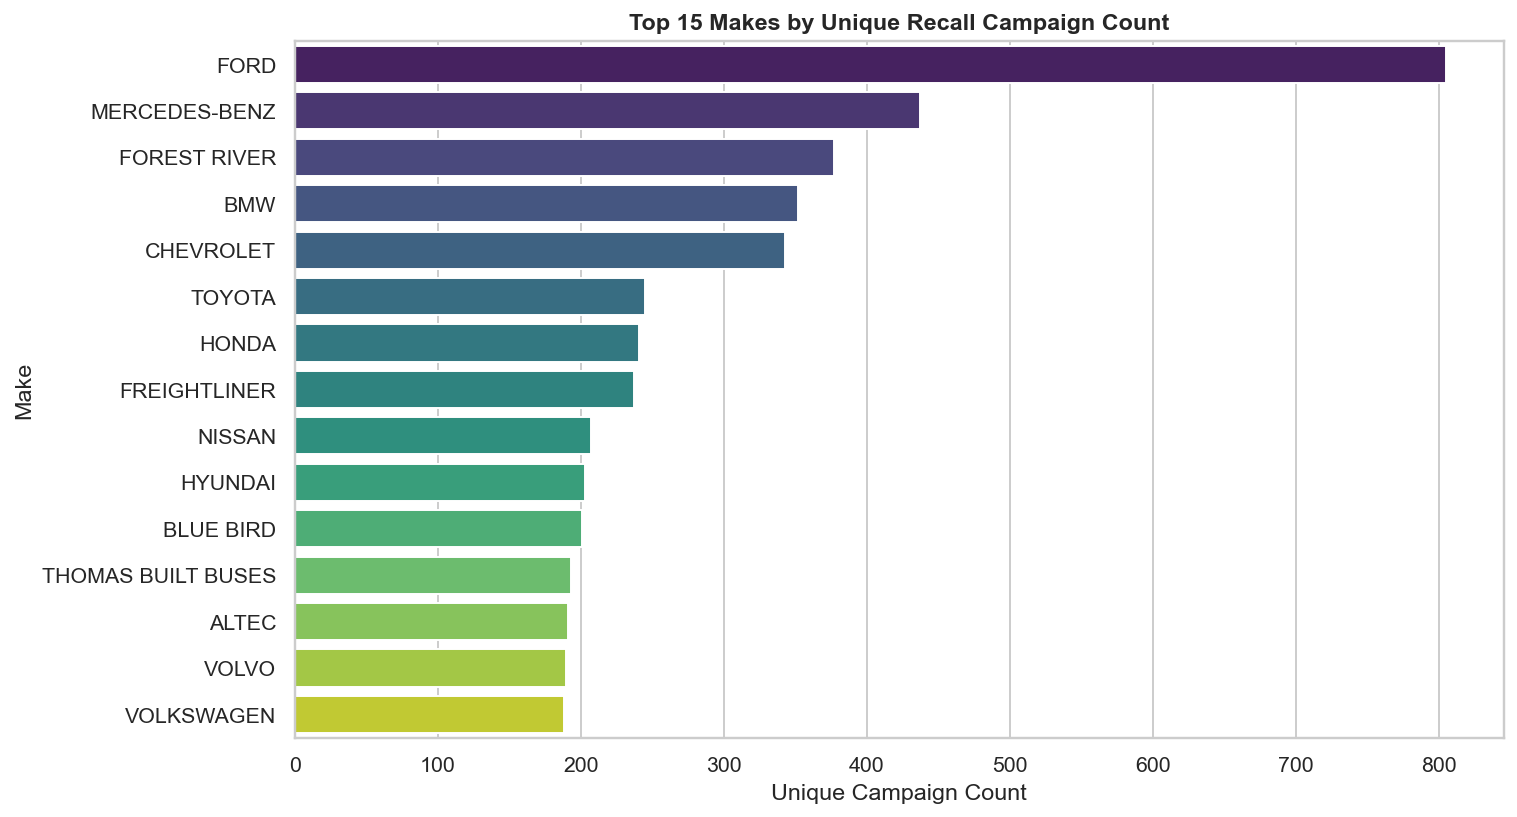

In [18]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_makes,
    x="Campaign Count",
    y="Make",
    hue="Make",
    palette=sns.color_palette("viridis", n_colors=len(top_makes)),
    dodge=False,
    legend=False
)

plt.title("Top 15 Makes by Unique Recall Campaign Count")
plt.xlabel("Unique Campaign Count")
plt.ylabel("Make")

save_plot("figure_02_top_makes")

In [19]:
# 10. Figure 3 - Top components

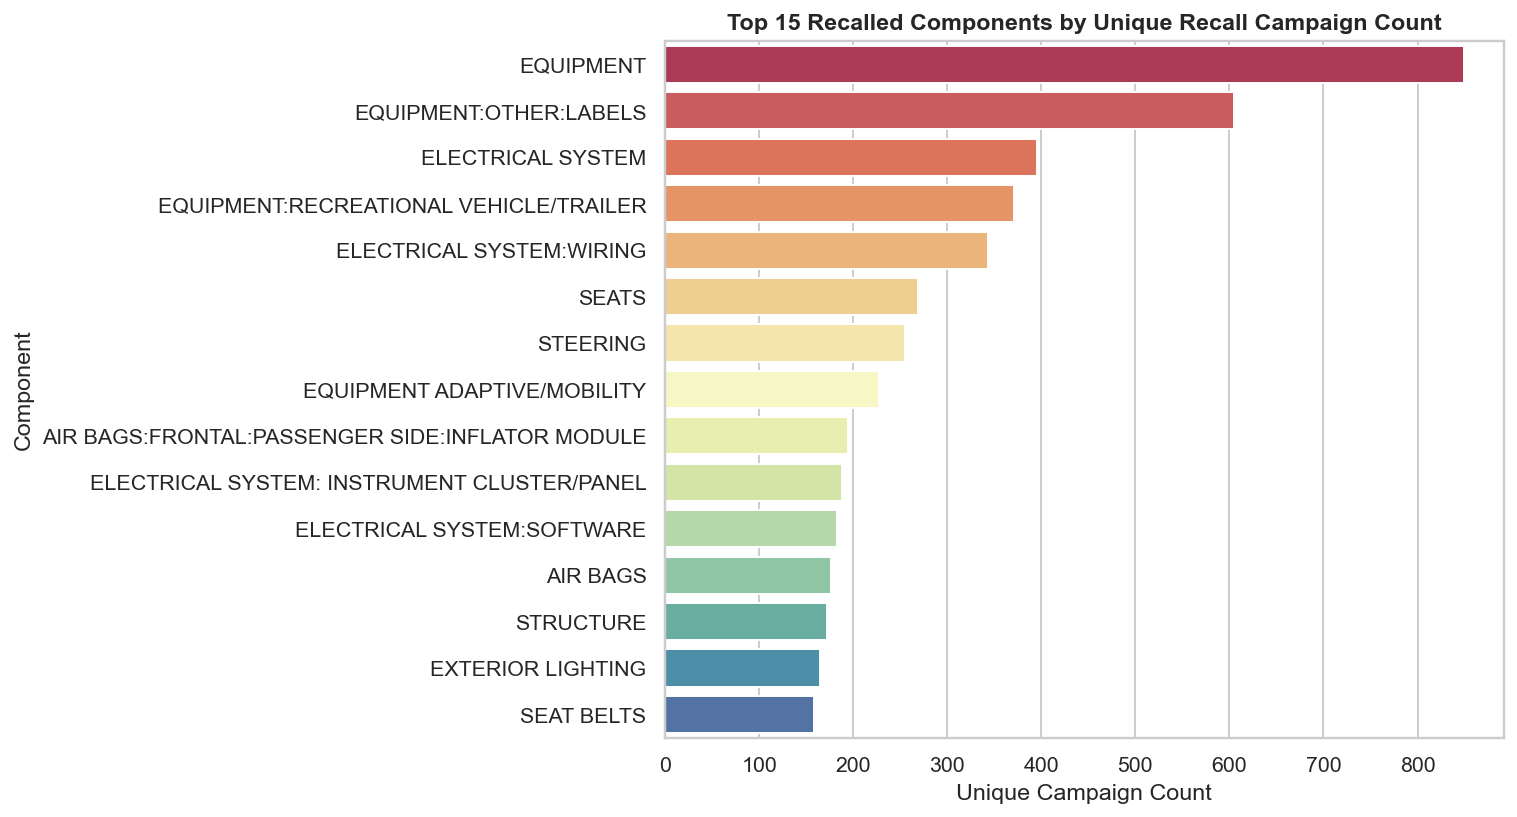

In [20]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_components,
    x="Campaign Count",
    y="Component",
    hue="Component",
    palette=sns.color_palette("Spectral", n_colors=len(top_components)),
    dodge=False,
    legend=False
)

plt.title("Top 15 Recalled Components by Unique Recall Campaign Count")
plt.xlabel("Unique Campaign Count")
plt.ylabel("Component")

save_plot("figure_03_top_components")

In [21]:
# 11. Figure 4 - Distribution of affected units

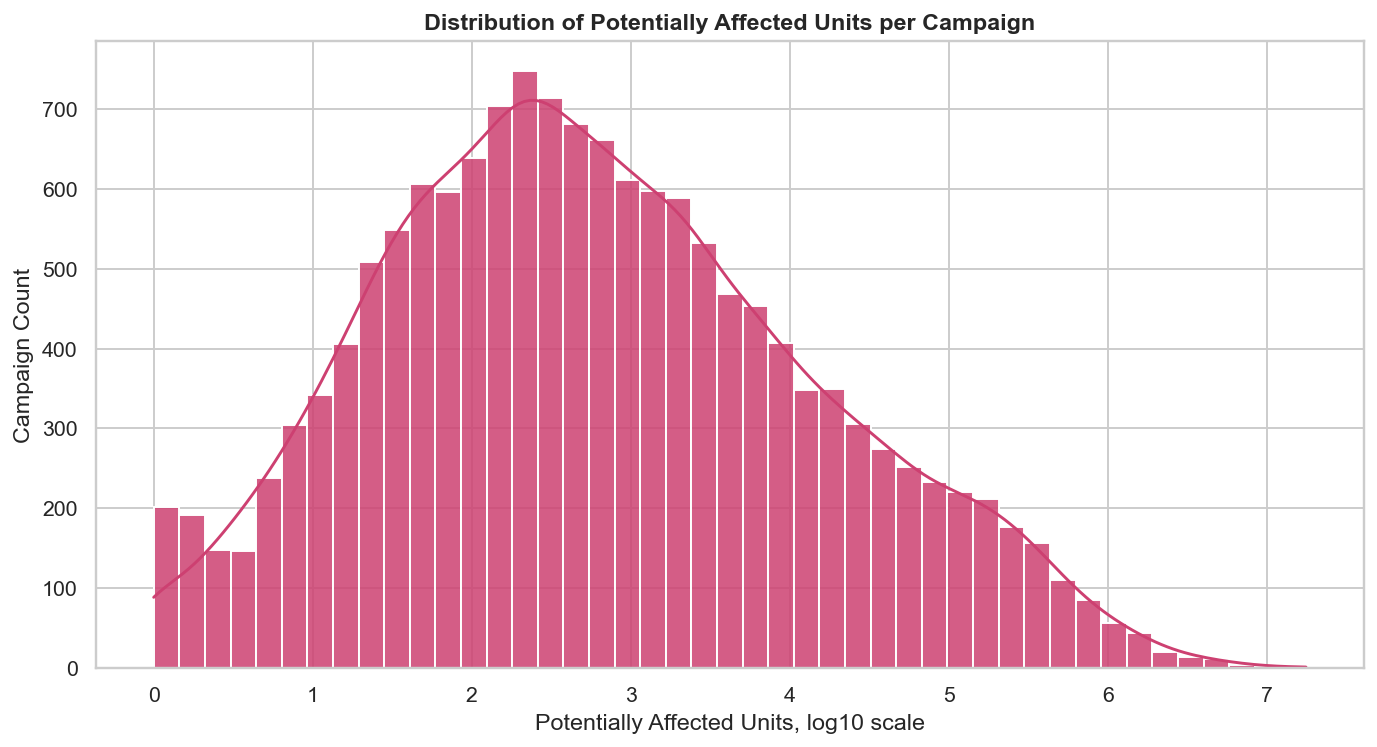

In [22]:
plt.figure(figsize=(10, 5.5))

sns.histplot(
    data=campaign,
    x="affected_log10",
    bins=45,
    kde=True,
    color=sns.color_palette("magma", 8)[4],
    edgecolor="white",
    alpha=0.85
)

plt.title("Distribution of Potentially Affected Units per Campaign")
plt.xlabel("Potentially Affected Units, log10 scale")
plt.ylabel("Campaign Count")

save_plot("figure_04_affected_distribution")

In [23]:
# 12. Figure 5 - Affected-unit spread by component

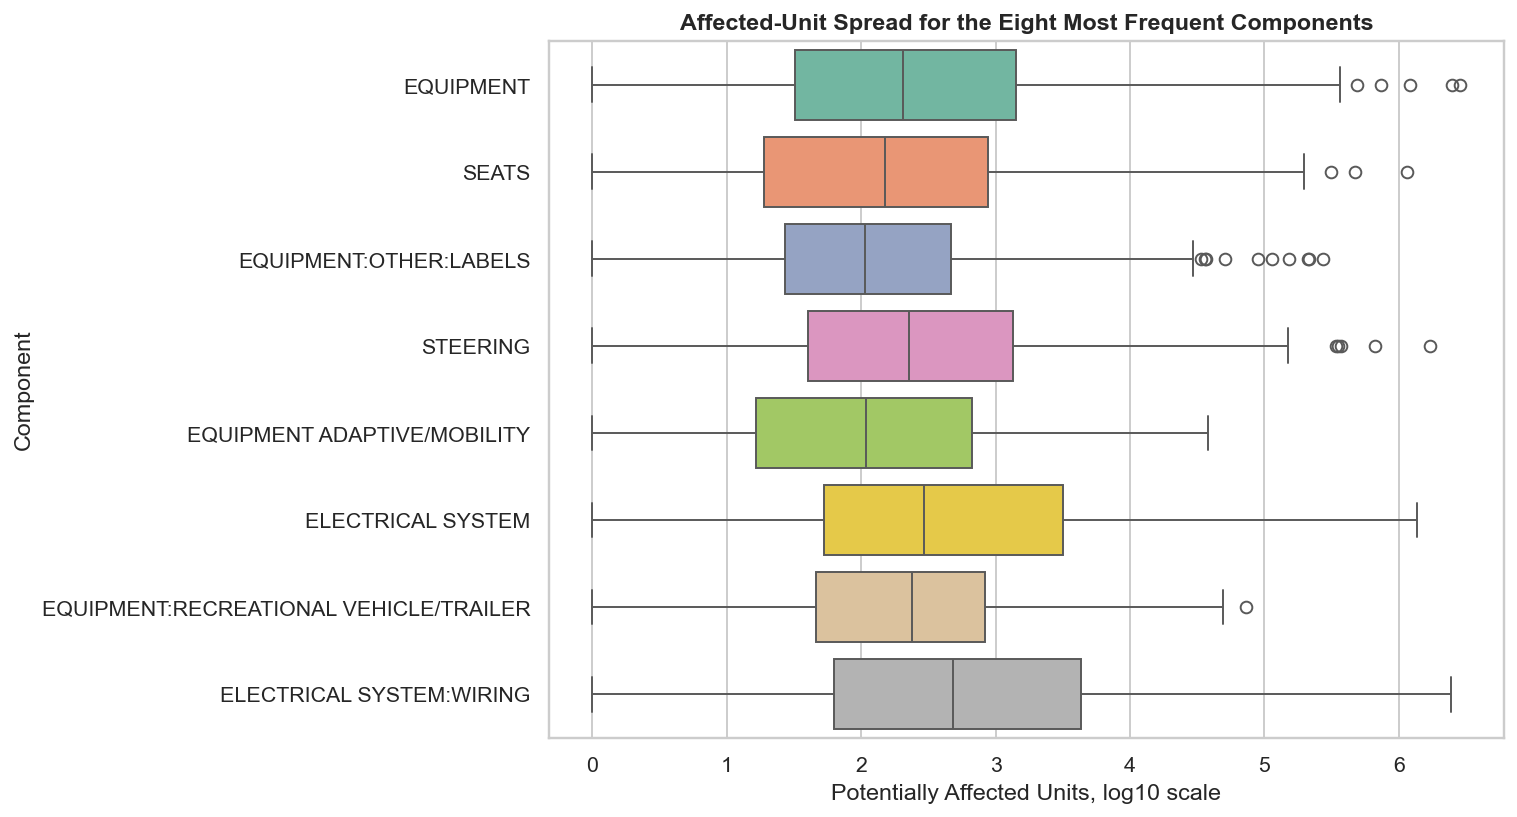

In [24]:
components8 = campaign["component"].value_counts().head(8).index
component_box_data = campaign[campaign["component"].isin(components8)].copy()

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=component_box_data,
    x="affected_log10",
    y="component",
    hue="component",
    palette=sns.color_palette("Set2", n_colors=component_box_data["component"].nunique()),
    dodge=False,
    legend=False
)

plt.title("Affected-Unit Spread for the Eight Most Frequent Components")
plt.xlabel("Potentially Affected Units, log10 scale")
plt.ylabel("Component")

save_plot("figure_05_component_boxplot")

In [25]:
# 13. Figure 6 - Component recall heatmap by year

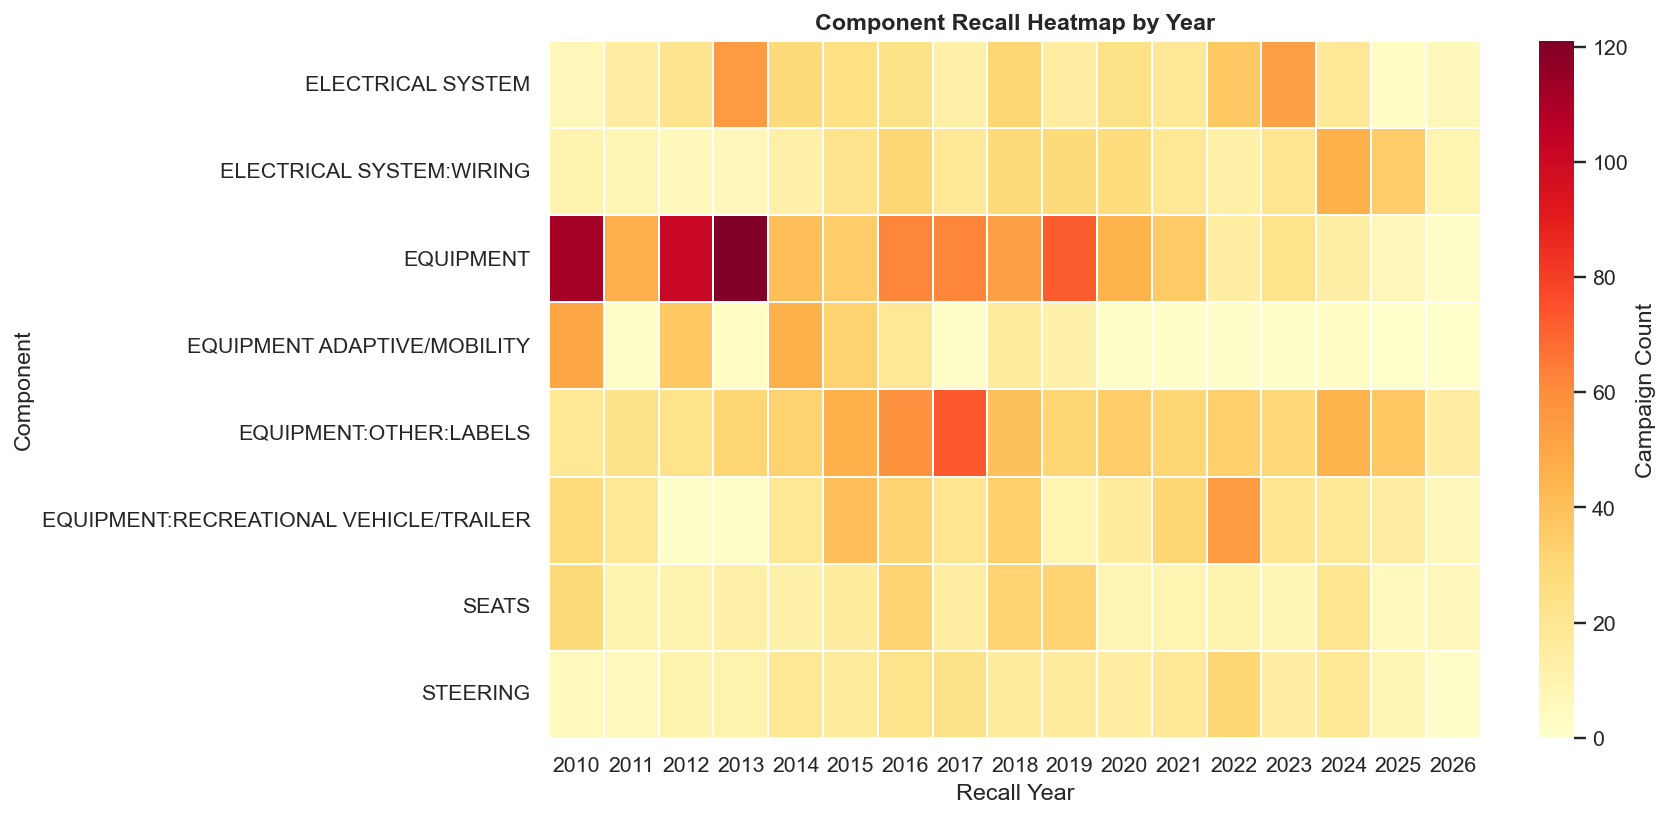

In [26]:
recent_components = campaign[
    (campaign["recall_year"] >= 2010) &
    (campaign["component"].isin(components8))
].copy()

component_year_pivot = recent_components.pivot_table(
    index="component",
    columns="recall_year",
    values="CAMPNO",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12.5, 6))

sns.heatmap(
    component_year_pivot,
    cmap="YlOrRd",
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Campaign Count"}
)

plt.title("Component Recall Heatmap by Year")
plt.xlabel("Recall Year")
plt.ylabel("Component")

save_plot("figure_06_component_year_heatmap")

In [27]:
# 14. Figure 7 - Special safety instructions

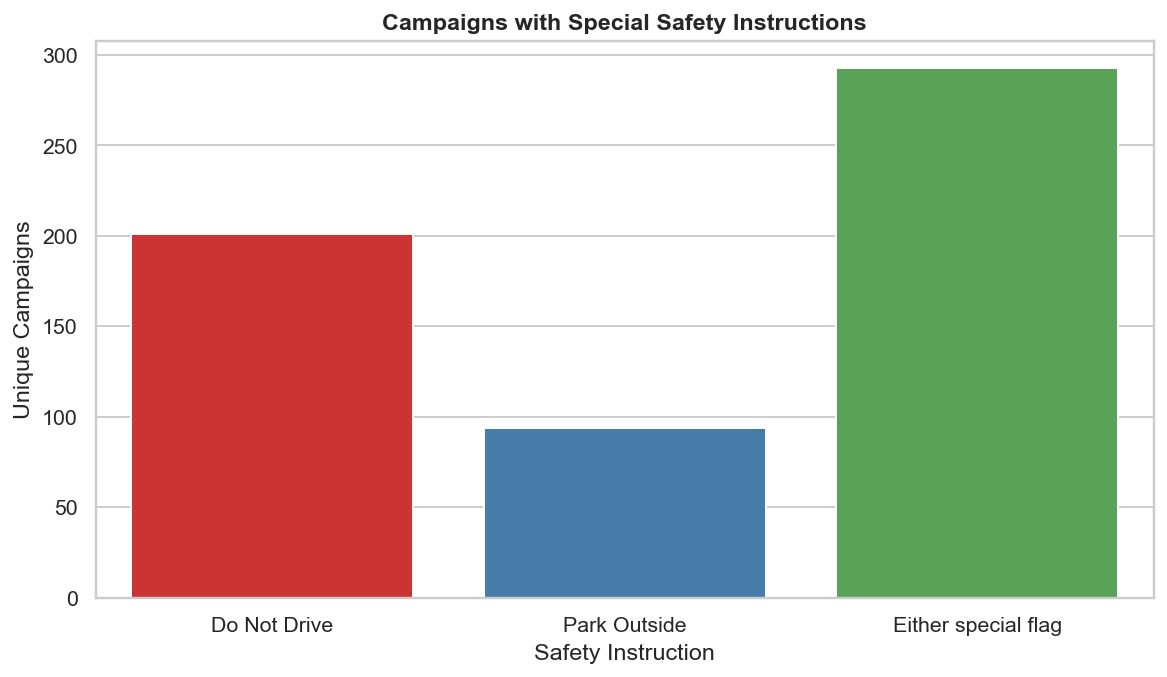

In [28]:
flag_counts = pd.DataFrame({
    "Flag": ["Do Not Drive", "Park Outside", "Either special flag"],
    "Campaign Count": [
        (campaign["do_not_drive"] == "YES").sum(),
        (campaign["park_outside"] == "YES").sum(),
        (campaign["safety_flag"] == "Special flag").sum()
    ]
})

plt.figure(figsize=(8.5, 5))

sns.barplot(
    data=flag_counts,
    x="Flag",
    y="Campaign Count",
    hue="Flag",
    palette=sns.color_palette("Set1", n_colors=3),
    dodge=False,
    legend=False
)

plt.title("Campaigns with Special Safety Instructions")
plt.xlabel("Safety Instruction")
plt.ylabel("Unique Campaigns")

save_plot("figure_07_safety_flags")

In [29]:
# 15. Figure 8 - Influencing source

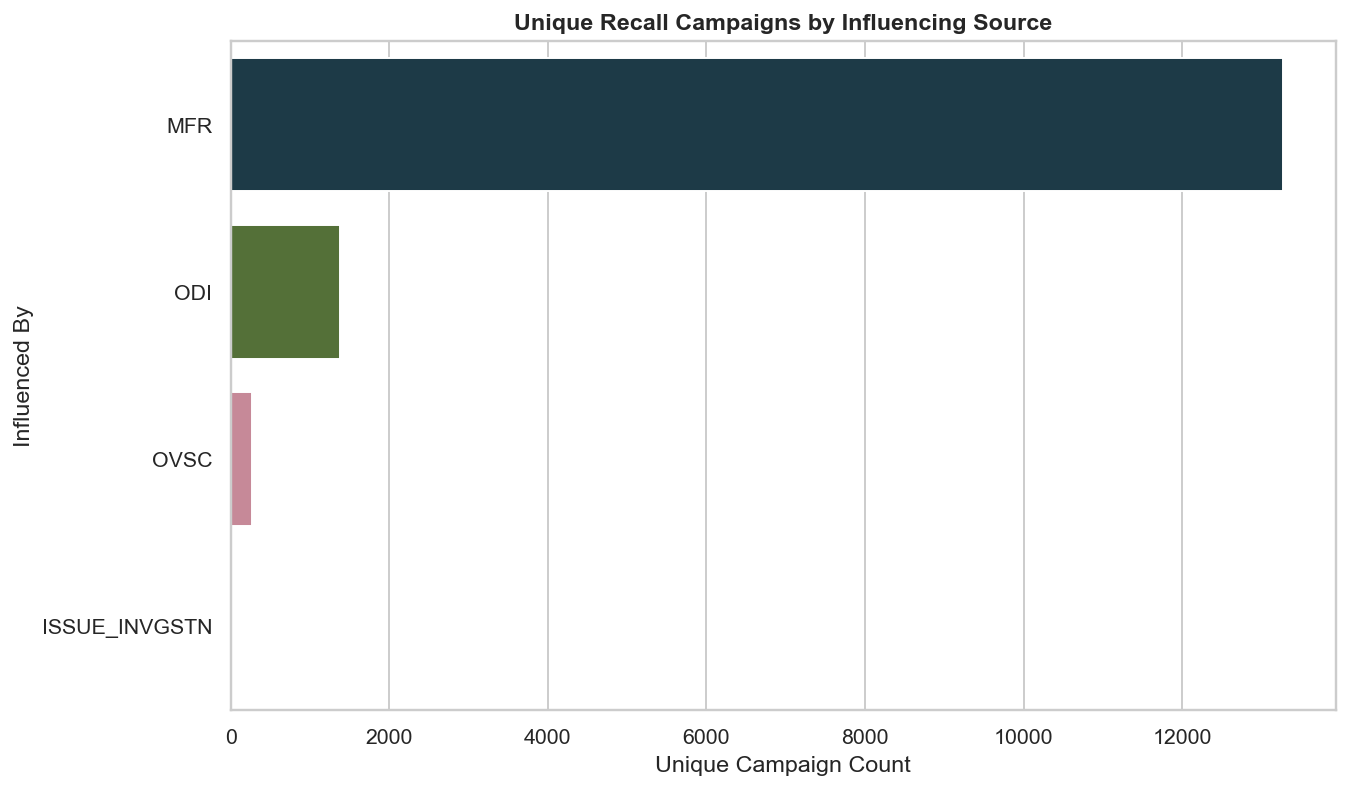

In [30]:
source_counts = (
    campaign["influenced_by"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(10)
    .reset_index()
)

source_counts.columns = ["Influenced By", "Campaign Count"]
source_counts.to_csv(TABLE_DIR / "influenced_by_summary.csv", index=False)

plt.figure(figsize=(9.8, 5.8))

sns.barplot(
    data=source_counts,
    x="Campaign Count",
    y="Influenced By",
    hue="Influenced By",
    palette=sns.color_palette("cubehelix", n_colors=len(source_counts)),
    dodge=False,
    legend=False
)

plt.title("Unique Recall Campaigns by Influencing Source")
plt.xlabel("Unique Campaign Count")
plt.ylabel("Influenced By")

save_plot("figure_08_influenced_by")

In [31]:
# 16. Figure 9 - Vehicle age at recall notice

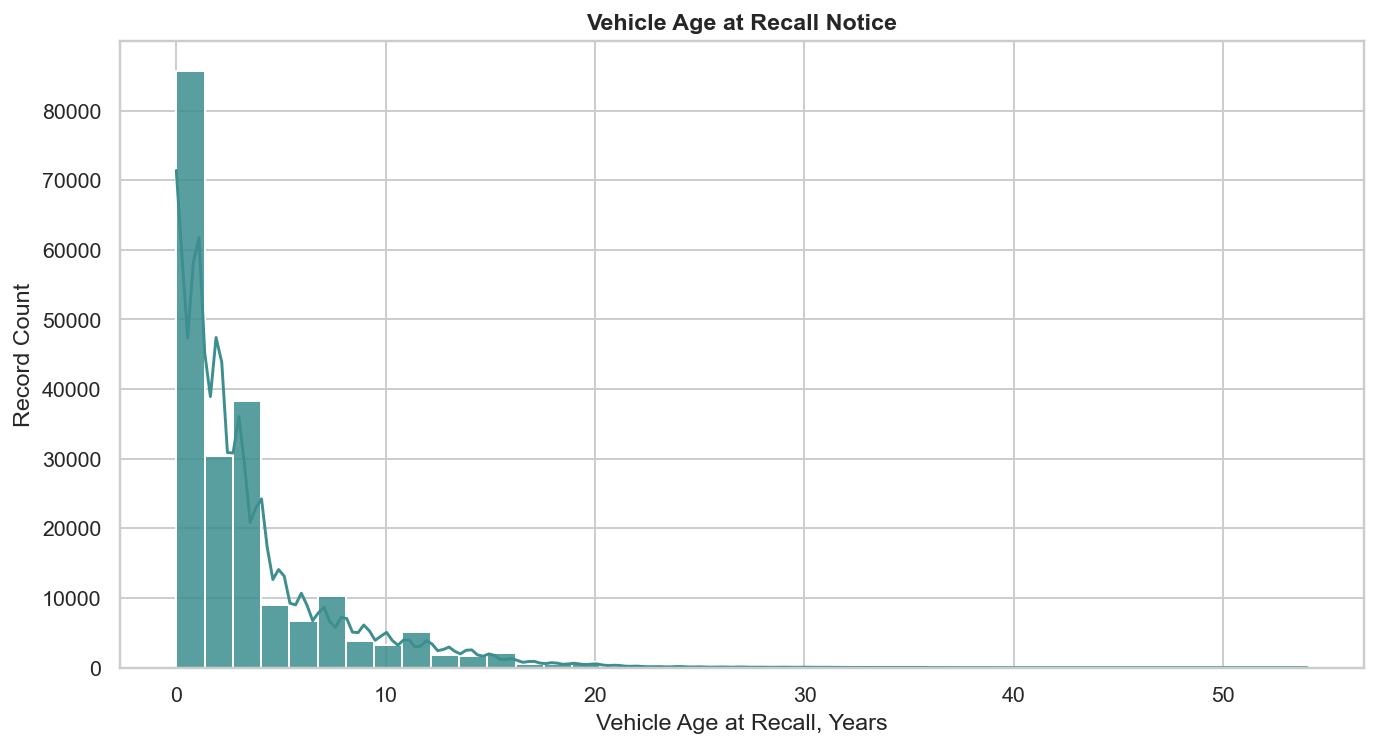

In [32]:
age_data = df.dropna(subset=["vehicle_age_at_recall"]).copy()

plt.figure(figsize=(10, 5.5))

sns.histplot(
    data=age_data,
    x="vehicle_age_at_recall",
    bins=40,
    kde=True,
    color=sns.color_palette("crest", 8)[3],
    edgecolor="white",
    alpha=0.85
)

plt.title("Vehicle Age at Recall Notice")
plt.xlabel("Vehicle Age at Recall, Years")
plt.ylabel("Record Count")

save_plot("figure_09_vehicle_age_distribution")

In [33]:
# 17. Figure 10 - Vehicle age vs campaign scale

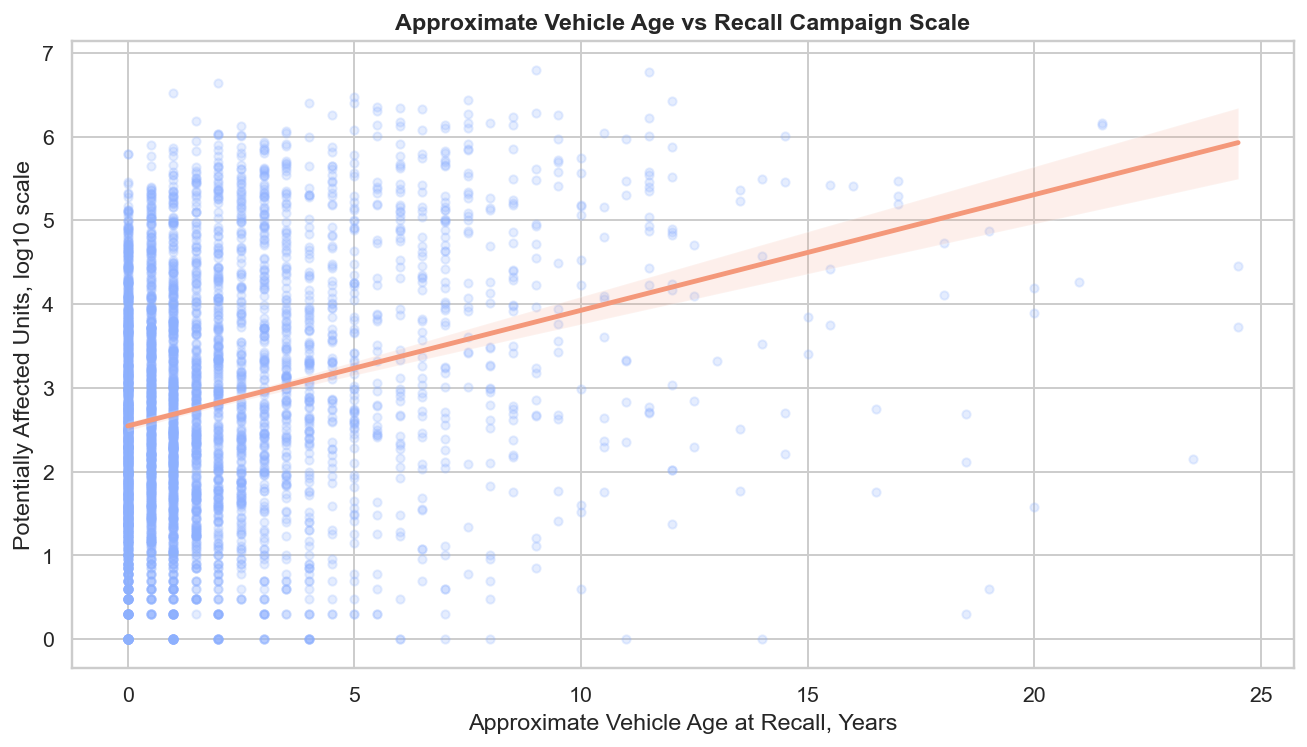

In [34]:
reg_data = campaign[
    ["approx_vehicle_age", "potential_affected", "model_year_span"]
].dropna().copy()

reg_data = reg_data[
    (reg_data["approx_vehicle_age"] >= 0) &
    (reg_data["approx_vehicle_age"] <= 40)
].copy()

# Sample points for readability
reg_sample = reg_data.sample(min(4000, len(reg_data)), random_state=42).copy()
reg_sample["affected_log10"] = np.log10(reg_sample["potential_affected"].clip(lower=1))

plt.figure(figsize=(9.5, 5.5))

sns.regplot(
    data=reg_sample,
    x="approx_vehicle_age",
    y="affected_log10",
    scatter_kws={
        "alpha": 0.22,
        "s": 18,
        "color": sns.color_palette("coolwarm", 7)[1]
    },
    line_kws={
        "linewidth": 2.5,
        "color": sns.color_palette("coolwarm", 7)[5]
    }
)

plt.title("Approximate Vehicle Age vs Recall Campaign Scale")
plt.xlabel("Approximate Vehicle Age at Recall, Years")
plt.ylabel("Potentially Affected Units, log10 scale")

save_plot("figure_10_age_vs_scale_regression")

In [35]:
# 18. Statistical analysis

In [36]:
affected = campaign["potential_affected"].dropna()
affected_log = np.log10(affected.clip(lower=1))

# Skewness and kurtosis
raw_skew = stats.skew(affected)
log_skew = stats.skew(affected_log)
raw_kurtosis = stats.kurtosis(affected)
log_kurtosis = stats.kurtosis(affected_log)

# Shapiro-Wilk test on sample
sample_affected = affected.sample(min(5000, len(affected)), random_state=42)
sample_affected_log = np.log10(sample_affected.clip(lower=1))

shapiro_raw = stats.shapiro(sample_affected)
shapiro_log = stats.shapiro(sample_affected_log)

# Correlation checks
age_corr_data = campaign[
    ["approx_vehicle_age", "potential_affected", "model_year_span"]
].dropna().copy()

age_corr_data = age_corr_data[
    (age_corr_data["approx_vehicle_age"] >= 0) &
    (age_corr_data["approx_vehicle_age"] <= 40)
].copy()

age_corr_data["affected_log10"] = np.log10(age_corr_data["potential_affected"].clip(lower=1))

pearson_age = stats.pearsonr(
    age_corr_data["approx_vehicle_age"],
    age_corr_data["affected_log10"]
)

spearman_span = stats.spearmanr(
    age_corr_data["model_year_span"],
    age_corr_data["affected_log10"]
)

stat_summary = pd.DataFrame({
    "Measure": [
        "Raw affected-unit skewness",
        "Log10 affected-unit skewness",
        "Raw affected-unit excess kurtosis",
        "Log10 affected-unit excess kurtosis",
        "Shapiro p-value, raw sample",
        "Shapiro p-value, log10 sample",
        "Pearson r: vehicle age vs log campaign scale",
        "Spearman rho: model-year span vs log scale"
    ],
    "Value": [
        round(raw_skew, 2),
        round(log_skew, 2),
        round(raw_kurtosis, 2),
        round(log_kurtosis, 2),
        f"{shapiro_raw.pvalue:.2e}",
        f"{shapiro_log.pvalue:.2e}",
        round(pearson_age.statistic, 2),
        round(spearman_span.statistic, 2)
    ]
})

stat_summary.to_csv(TABLE_DIR / "statistical_summary.csv", index=False)

print("\nStatistical summary:")
print(stat_summary)


Statistical summary:
                                        Measure     Value
0                    Raw affected-unit skewness     23.86
1                  Log10 affected-unit skewness       0.3
2             Raw affected-unit excess kurtosis    965.88
3           Log10 affected-unit excess kurtosis     -0.42
4                   Shapiro p-value, raw sample  2.32e-92
5                 Shapiro p-value, log10 sample  6.68e-20
6  Pearson r: vehicle age vs log campaign scale      0.26
7    Spearman rho: model-year span vs log scale      0.31


In [37]:
# 19. Final export

In [38]:
df.to_csv("cleaned_record_level_data.csv", index=False)
campaign.to_csv("cleaned_campaign_level_data.csv", index=False)

print("\nProject outputs saved successfully.")
print("Saved figures in:", FIG_DIR.resolve())
print("Saved tables in:", TABLE_DIR.resolve())
print("Saved cleaned campaign-level data: cleaned_campaign_level_data.csv")
print("Saved cleaned record-level data: cleaned_record_level_data.csv")


Project outputs saved successfully.
Saved figures in: C:\Users\gshwe\Downloads\figures
Saved tables in: C:\Users\gshwe\Downloads\tables
Saved cleaned campaign-level data: cleaned_campaign_level_data.csv
Saved cleaned record-level data: cleaned_record_level_data.csv
